In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

In [4]:
data_path = "/Users/pavithrameddaduwage/sigiriya-weather-forecast/data/"

# Fixed filenames: corrected "sigirya" to "sigiriya" and "corwd" to "crowd"
df1 = pd.read_csv(data_path + "sigiriya_2023_crowd.csv")
df2 = pd.read_csv(data_path + "sigiriya_2024_crowd.csv")
df3 = pd.read_csv(data_path + "sigiriya_2025_crowd.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.head()

,date,year,month,day_of_week,is_weekend,foreign_visitors_daily,local_visitors_daily,total_visitors_daily,peak_season_flag,holiday_flag
0,2023-01-01,2023,1,Sunday,1,1151,1939,3090,1,0
1,2023-01-02,2023,1,Monday,0,902,1160,2062,1,0
2,2023-01-03,2023,1,Tuesday,0,698,1052,1750,1,0
3,2023-01-04,2023,1,Wednesday,0,907,2073,2980,1,0
4,2023-01-05,2023,1,Thursday,0,698,818,1516,1,0


In [5]:
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

# Lag Features (important for time series)
df['lag_1'] = df['total_visitors_daily'].shift(1)
df['lag_7'] = df['total_visitors_daily'].shift(7)
df['rolling_mean_7'] = df['total_visitors_daily'].rolling(7).mean()

df = df.dropna()

In [6]:
features = [
    'month',
    'is_weekend',
    'peak_season_flag',
    'holiday_flag',
    'day_of_year',
    'week_of_year',
    'quarter',
    'lag_1',
    'lag_7',
    'rolling_mean_7'
]

X = df[features]
y = df['total_visitors_daily']

In [7]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    n_jobs=2
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2:", r2_score(y_test, xgb_pred))

XGBoost Results
MAE: 373.8900451660156
RMSE: 521.8452835850871
R2: 0.6920984387397766


In [9]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=2
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 369.6901501446835
RMSE: 522.448129004197
R2: 0.6913866258994623


In [10]:
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gbr_model.fit(X_train, y_train)

gbr_pred = gbr_model.predict(X_test)

print("Gradient Boosting Results")
print("MAE:", mean_absolute_error(y_test, gbr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gbr_pred)))
print("R2:", r2_score(y_test, gbr_pred))

Gradient Boosting Results
MAE: 376.9053449816768
RMSE: 529.2204656466444
R2: 0.6833338459918592


In [11]:
model_path = "/Users/pavithrameddaduwage/sigiriya-weather-forecast/models/"

joblib.dump(xgb_model, model_path + "best_sigiriya_model.pkl")

['/Users/pavithrameddaduwage/sigiriya-weather-forecast/models/best_sigiriya_model.pkl']

In [12]:
future_dates = pd.date_range(start="2026-01-01", end="2026-12-31")

future_df = pd.DataFrame({'date': future_dates})

future_df['month'] = future_df['date'].dt.month
future_df['is_weekend'] = (future_df['date'].dt.dayofweek >= 5).astype(int)
future_df['peak_season_flag'] = future_df['month'].isin([1,7,8,12]).astype(int)
future_df['holiday_flag'] = 0
future_df['day_of_year'] = future_df['date'].dt.dayofyear
future_df['week_of_year'] = future_df['date'].dt.isocalendar().week.astype(int)
future_df['quarter'] = future_df['date'].dt.quarter

# Use last known values for lag features
last_values = df.iloc[-7:]['total_visitors_daily'].values

future_df['lag_1'] = last_values[-1]
future_df['lag_7'] = last_values[0]
future_df['rolling_mean_7'] = np.mean(last_values)

future_predictions = xgb_model.predict(future_df[features])

future_df['predicted_crowd'] = future_predictions

future_df.head()

,date,month,is_weekend,peak_season_flag,holiday_flag,day_of_year,week_of_year,quarter,lag_1,lag_7,rolling_mean_7,predicted_crowd
0,2026-01-01,1,0,1,0,1,1,1,2960,2129,2770.285714,1539.313110
1,2026-01-02,1,0,1,0,2,1,1,2960,2129,2770.285714,1539.313110
2,2026-01-03,1,1,1,0,3,1,1,2960,2129,2770.285714,3077.096680
3,2026-01-04,1,1,1,0,4,1,1,2960,2129,2770.285714,3077.096680
4,2026-01-05,1,0,1,0,5,2,1,2960,2129,2770.285714,1476.960083


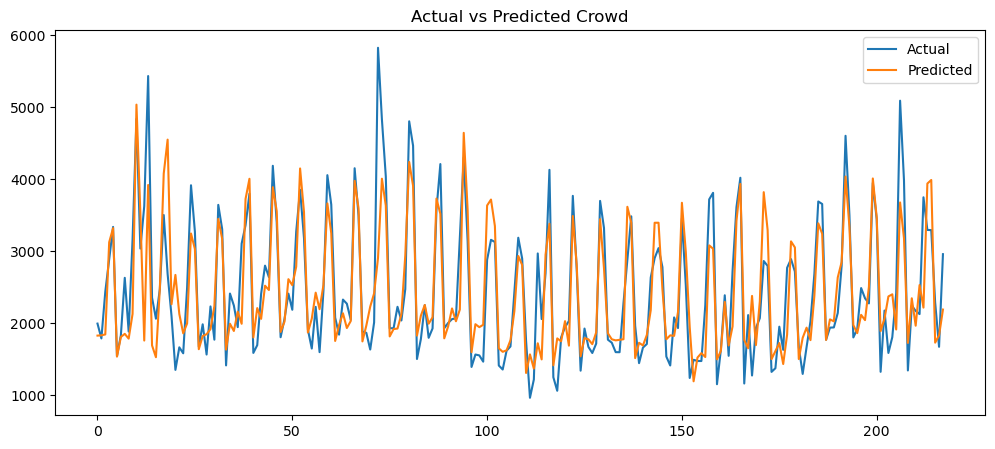

In [13]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Crowd")
plt.show()

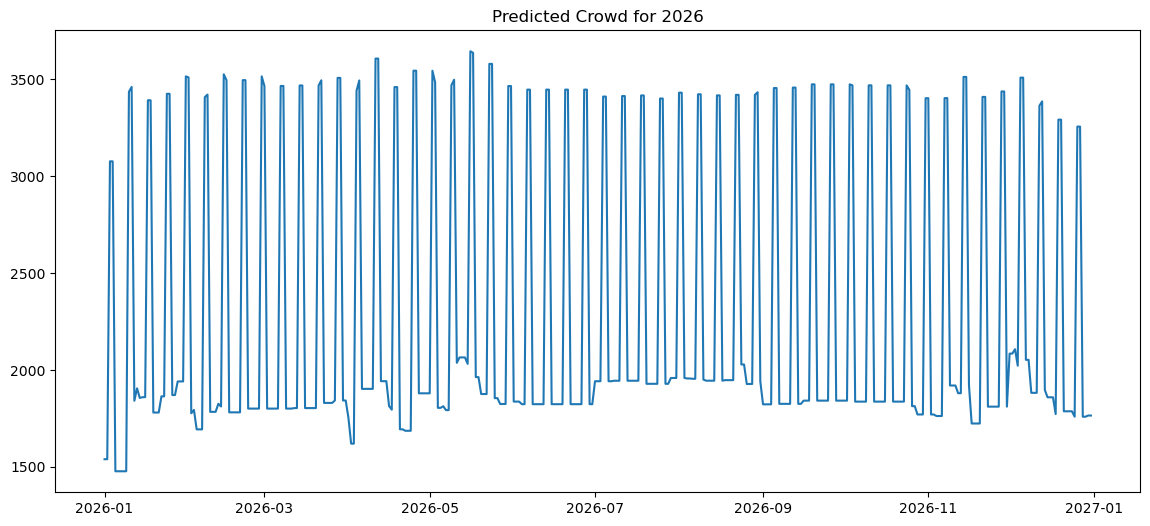

In [14]:
plt.figure(figsize=(14,6))
plt.plot(future_df['date'], future_df['predicted_crowd'])
plt.title("Predicted Crowd for 2026")
plt.show()

In [15]:
def crowd_on_date(date_input):
    date_input = pd.to_datetime(date_input)
    result = future_df[future_df['date'] == date_input]
    return result['predicted_crowd'].values[0]


def crowd_next_month():
    next_month = future_df[future_df['date'].dt.month == pd.Timestamp.today().month + 1]
    return next_month['predicted_crowd'].sum()


def crowd_this_week():
    today = pd.Timestamp.today()
    week = future_df[future_df['date'].dt.isocalendar().week == today.isocalendar().week]
    return week['predicted_crowd'].sum()